# Bounding Box Annotation — Aïoli & Mayo

Interactive tool for labelling cat photos with YOLO-format bounding boxes.

**Workflow:**
1. Each image is displayed one at a time.
2. **Draw** a bounding box by clicking and dragging on the image.
3. Select the correct cat (**Aïoli** or **Mayo**) from the dropdown.
4. Draw additional boxes if both cats are visible.
5. Click **Confirm** to save and advance, **Mark Empty** if no cat is visible, or **Skip** to return later.

Labels are saved immediately on confirm — progress is never lost.

In [1]:
%matplotlib widget

import sys
from pathlib import Path

# Ensure the project root is on the Python path so that `src` is importable.
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils import setup_logging
from src.annotate import AnnotationSession, AnnotationWidget, get_class_distribution

setup_logging()

In [2]:
RAW_DIR = project_root / "data" / "raw"
LABELS_DIR = project_root / "data" / "labels"
LABELS_DIR.mkdir(parents=True, exist_ok=True)

session = AnnotationSession(raw_dir=RAW_DIR, labels_dir=LABELS_DIR)

In [3]:
print(
    f"{session.annotated_count} of {session.total_images} images annotated "
    f"— {session.remaining_count} remaining."
)

255 of 255 images annotated — 0 remaining.


## Annotation

Draw bounding boxes on each image below. Use the **Cat** dropdown to select the correct label before drawing. Click **Confirm** to save and move to the next image.

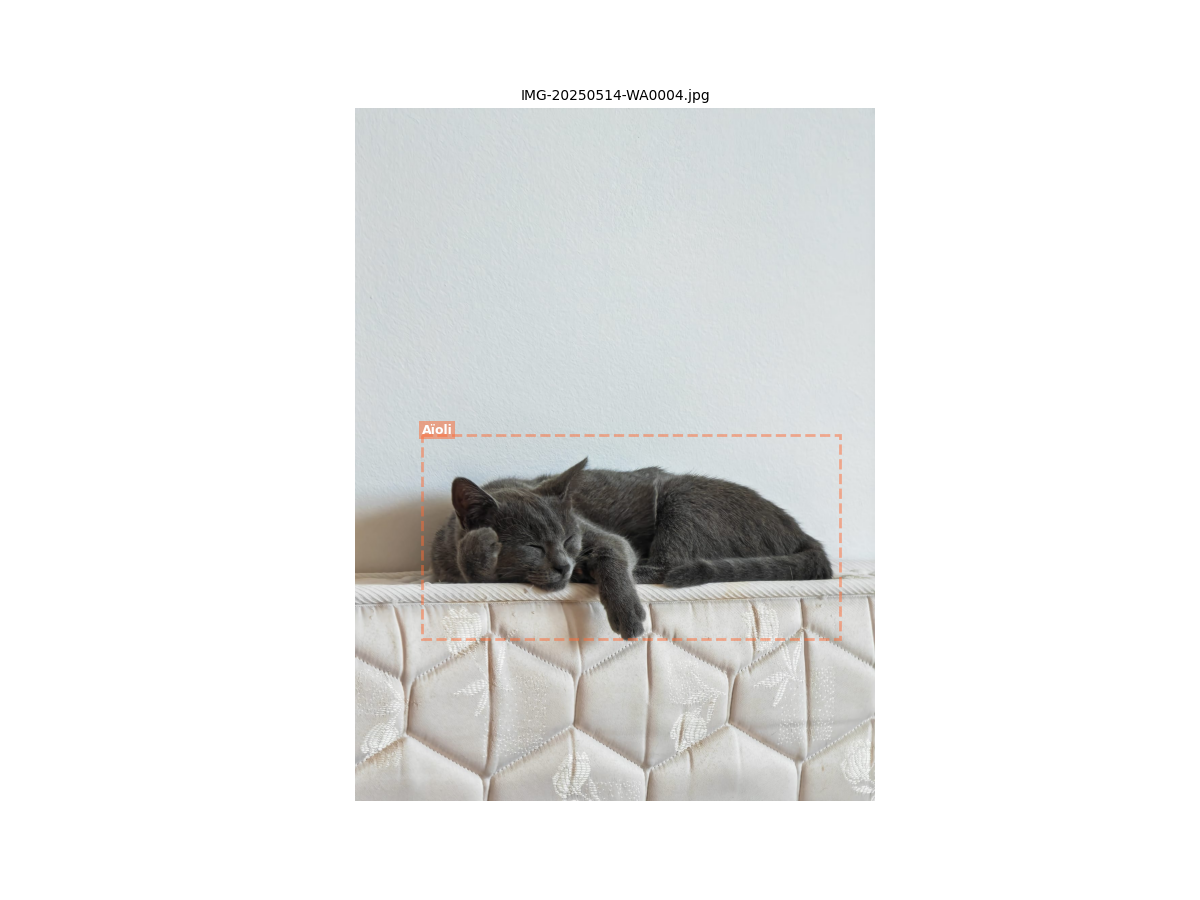

In [4]:
widget = AnnotationWidget(session)
widget.display()

## Class Distribution

Run this cell after annotating to see how many appearances of each cat have been labelled.

In [ ]:
dist = get_class_distribution(LABELS_DIR)
for name, count in dist.items():
    print(f"  {name}: {count} appearances")

total_files = len(list(LABELS_DIR.glob("*.txt")))
print(f"  Total label files: {total_files}")